## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

def reconstruct_with_given_kernel_params(X, kernel_params):

    x_input = torch.tensor(X).float()
    
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    plt.plot(z_mu[0].detach(),'o')
    plt.gca().set_prop_cycle(None)
    
    # Update kernel_params
    kernel_params = torch.tensor(kernel_params).reshape(1,1,4).repeat(z_mu.shape[0],z_mu.shape[2],1)
    
    # Correct with GP
    z_star = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params)

    plt.plot(z_star[0].detach())

    plt.show()

    
    # Reconstruct and compute reconstruction error
    x_recon = gpvae.model.backbone.decode(z_star).mean

    x_input[x_input==0] = torch.nan

    return x_input, x_recon

## Generate latent time series of size n_dimensions

In [68]:
# Parameters
n_groups = 1
n_observations_per_group = 5000
n_dimensions = 30
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

100%|██████████████████████████████████████| 5000/5000 [00:17<00:00, 288.79it/s]


## Project this time series into a random space of size n_new_dims

In [69]:
n_new_dims = 7
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

## Create an artificially corrupted dataset by imputing a ratio of p_dataset of your dataset

In [70]:
def corrupt_by_dim(X):
    """
    Corrupt by taking away some dimensions fully
    """
    X_corr = np.copy(X)
    T, n_dims = X.shape[1], X.shape[2]
    for x in X_corr:
        nb_obs_vals = np.random.randint(0,5)
        obs_mask = np.random.choice(np.arange(T), size = T - nb_obs_vals, replace = False)
        obs_mask = np.isin(np.arange(T), obs_mask)
        n_dims_missing = np.random.randint(1,4)
        dims = np.random.choice(np.arange(n_dims), size = n_dims_missing, replace = False)
        for dim in dims:
            x[obs_mask,dim] = np.nan

    return X_corr

In [71]:
from pygrinder import mcar
# Normalize

p_dataset = .3

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
#X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X = corrupt_by_dim(X_normalized.copy())
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

In [72]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

latent_size = 15

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = latent_size, #desired latent size, chosen as bigger thant the actual latent space of size 10
            epochs = 200, 
            batch_size = 64,
            beta = 1., #beta weight which is redefined underneath for clarity
            K = 3,  # number of samples from the latent distribution 
            encoder_sizes = (128,64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam() #lr = 1e-4
            )

from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.model.backbone.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)


gpvae.model.backbone.alpha = 1e1   # weight of KL between q(z|x_observed) et q(z|x_observed_corrompu)
gpvae.model.backbone.beta = 1e0       # weight of prior on latent space (c'est juste une regularisation, je force l'espace latent a etre centré en 0)
gpvae.model.backbone.gamma = 1e-5   # weight of time coherence loss (2 consecutive latent observations z_t and z_{t+1} must be close modulo
                                    # the difference between the observed data X_t and X_{t+1} and the latent variance
gpvae.model.backbone.sampling = True # wether or not we add a sampling scheme to approximate x_missing|x_observed to force
                                     # encode the imputed sample x_sampled = (x_missing|x_observed, x_observed) such that
                                     # q(z|x_sampled) to be included in q(z|x_observed)

#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train)  # train the model on the dataset

2025-01-22 11:28:27 [INFO]: No given device, using default device: cpu
2025-01-22 11:28:27 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-01-22 11:28:27 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 16,581


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=15, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=15, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


2025-01-22 11:28:32 [INFO]: Epoch 001 - training loss: 42.9001
2025-01-22 11:28:36 [INFO]: Epoch 002 - training loss: 18.9082
2025-01-22 11:28:40 [INFO]: Epoch 003 - training loss: 17.4990
2025-01-22 11:28:44 [INFO]: Epoch 004 - training loss: 16.6903
2025-01-22 11:28:48 [INFO]: Epoch 005 - training loss: 15.6179
2025-01-22 11:28:52 [INFO]: Epoch 006 - training loss: 15.1210
2025-01-22 11:28:55 [INFO]: Epoch 007 - training loss: 14.8162
2025-01-22 11:28:59 [INFO]: Epoch 008 - training loss: 14.6177
2025-01-22 11:29:03 [INFO]: Epoch 009 - training loss: 14.4314
2025-01-22 11:29:07 [INFO]: Epoch 010 - training loss: 14.2042
2025-01-22 11:29:10 [INFO]: Epoch 011 - training loss: 13.8405
2025-01-22 11:29:14 [INFO]: Epoch 012 - training loss: 13.4600
2025-01-22 11:29:18 [INFO]: Epoch 013 - training loss: 13.1808
2025-01-22 11:29:22 [INFO]: Epoch 014 - training loss: 12.8214


plotting


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:766: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
2025-01-22 11:29:26 [INFO]: Epoch 015 - training loss: 12.6180
2025-01-22 11:29:30 [INFO]: Epoch 016 - training loss: 12.4538
2025-01-22 11:29:34 [INFO]: Epoch 017 - training loss: 12.2782
2025-01-22 11:29:37 [INFO]: Epoch 018 - training loss: 12.1143
2025-01-22 11:29:41 [INFO]: Epoch 019 - training loss: 11.9733
2025-01-22 11:29:45 [INFO]: Epoch 020 - training loss: 11.8650
2025-01-22 11:29:49 [INFO]: Epoch 021 - training loss: 11.7230
2025-01-22 11:29:53 [INFO]: Epoch 022 - training loss: 11.6343
2025-01-22 11:29:56 [INFO]: Epoch 023 - training loss: 11.6496
2025-01-22 11:30:00 [INFO]: Epoch 024 - training loss: 11.6064
2025-01-22 11:30:04 [INFO]: Epoch 025 - training loss: 11.5879
2025-01-22 11:30:07 [INFO]: Epoch 026 - training loss: 11.5739
2

...

2025-01-22 11:38:27 [INFO]: Epoch 160 - training loss: 12.1580
2025-01-22 11:38:30 [INFO]: Epoch 161 - training loss: 12.1523
2025-01-22 11:38:34 [INFO]: Epoch 162 - training loss: 12.1415
2025-01-22 11:38:38 [INFO]: Epoch 163 - training loss: 12.1449
2025-01-22 11:38:42 [INFO]: Epoch 164 - training loss: 12.1870
2025-01-22 11:38:46 [INFO]: Epoch 165 - training loss: 12.1646
2025-01-22 11:38:49 [INFO]: Epoch 166 - training loss: 12.1392
2025-01-22 11:38:53 [INFO]: Epoch 167 - training loss: 12.1444
2025-01-22 11:38:57 [INFO]: Epoch 168 - training loss: 12.1613
2025-01-22 11:39:00 [INFO]: Epoch 169 - training loss: 12.1382
2025-01-22 11:39:05 [INFO]: Epoch 170 - training loss: 12.1539
2025-01-22 11:39:08 [INFO]: Epoch 171 - training loss: 12.1628
2025-01-22 11:39:12 [INFO]: Epoch 172 - training loss: 12.1561
2025-01-22 11:39:16 [INFO]: Epoch 173 - training loss: 12.1637
2025-01-22 11:39:20 [INFO]: Epoch 174 - training loss: 12.1888


plotting


2025-01-22 11:39:25 [INFO]: Epoch 175 - training loss: 12.1449
2025-01-22 11:39:28 [INFO]: Epoch 176 - training loss: 12.1781
2025-01-22 11:39:32 [INFO]: Epoch 177 - training loss: 12.1500
2025-01-22 11:39:35 [INFO]: Epoch 178 - training loss: 12.1321
2025-01-22 11:39:39 [INFO]: Epoch 179 - training loss: 12.1682
2025-01-22 11:39:43 [INFO]: Epoch 180 - training loss: 12.1679
2025-01-22 11:39:47 [INFO]: Epoch 181 - training loss: 12.1712
2025-01-22 11:39:50 [INFO]: Epoch 182 - training loss: 12.1684
2025-01-22 11:39:54 [INFO]: Epoch 183 - training loss: 12.1612
2025-01-22 11:39:57 [INFO]: Epoch 184 - training loss: 12.1609
2025-01-22 11:40:01 [INFO]: Epoch 185 - training loss: 12.1590
2025-01-22 11:40:04 [INFO]: Epoch 186 - training loss: 12.1425
2025-01-22 11:40:08 [INFO]: Epoch 187 - training loss: 12.1631
2025-01-22 11:40:11 [INFO]: Epoch 188 - training loss: 12.1392
2025-01-22 11:40:15 [INFO]: Epoch 189 - training loss: 12.1865


plotting


2025-01-22 11:40:19 [INFO]: Epoch 190 - training loss: 12.1207
2025-01-22 11:40:23 [INFO]: Epoch 191 - training loss: 12.1661
2025-01-22 11:40:27 [INFO]: Epoch 192 - training loss: 12.1616
2025-01-22 11:40:30 [INFO]: Epoch 193 - training loss: 12.1808
2025-01-22 11:40:34 [INFO]: Epoch 194 - training loss: 12.1404
2025-01-22 11:40:38 [INFO]: Epoch 195 - training loss: 12.1766
2025-01-22 11:40:42 [INFO]: Epoch 196 - training loss: 12.1464
2025-01-22 11:40:46 [INFO]: Epoch 197 - training loss: 12.1665
2025-01-22 11:40:49 [INFO]: Epoch 198 - training loss: 12.1572
2025-01-22 11:40:53 [INFO]: Epoch 199 - training loss: 12.1643
2025-01-22 11:40:57 [INFO]: Epoch 200 - training loss: 12.1730
2025-01-22 11:40:57 [INFO]: Finished training. The best model is from epoch#28.


In [73]:
gpvae.fit(dataset_train)  # train the model on the dataset

2025-01-22 11:41:01 [INFO]: Epoch 001 - training loss: 12.1529
2025-01-22 11:41:04 [INFO]: Epoch 002 - training loss: 12.1308
2025-01-22 11:41:08 [INFO]: Epoch 003 - training loss: 12.1562


plotting


2025-01-22 11:41:13 [INFO]: Epoch 004 - training loss: 12.1660
2025-01-22 11:41:16 [INFO]: Epoch 005 - training loss: 12.1299
2025-01-22 11:41:20 [INFO]: Epoch 006 - training loss: 12.1603
2025-01-22 11:41:23 [INFO]: Epoch 007 - training loss: 12.1280
2025-01-22 11:41:27 [INFO]: Epoch 008 - training loss: 12.1539
2025-01-22 11:41:31 [INFO]: Epoch 009 - training loss: 12.1453
2025-01-22 11:41:35 [INFO]: Epoch 010 - training loss: 12.1812
2025-01-22 11:41:39 [INFO]: Epoch 011 - training loss: 12.1215
2025-01-22 11:41:42 [INFO]: Epoch 012 - training loss: 12.1633
2025-01-22 11:41:46 [INFO]: Epoch 013 - training loss: 12.1214
2025-01-22 11:41:49 [INFO]: Epoch 014 - training loss: 12.1493
2025-01-22 11:41:53 [INFO]: Epoch 015 - training loss: 12.1483
2025-01-22 11:41:57 [INFO]: Epoch 016 - training loss: 12.1427
2025-01-22 11:41:57 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-01-22 11:41:57 [INFO]: Finished training. The best model is from epoch#13.


In [80]:
gpvae.model.backbone.alpha = 1e1
for i,param in enumerate(gpvae.model.backbone.decoder.parameters()):
    #if i!=0:
    param.requires_grad = False
gpvae.fit(dataset_train)  # train the model on the dataset

2025-01-22 14:54:18 [INFO]: Epoch 001 - training loss: 12.2535
2025-01-22 14:54:22 [INFO]: Epoch 002 - training loss: 12.1400
2025-01-22 14:54:27 [INFO]: Epoch 003 - training loss: 12.1050
2025-01-22 14:54:32 [INFO]: Epoch 004 - training loss: 12.1335
2025-01-22 14:54:37 [INFO]: Epoch 005 - training loss: 12.1283


plotting


2025-01-22 14:54:43 [INFO]: Epoch 006 - training loss: 12.1203
2025-01-22 14:54:49 [INFO]: Epoch 007 - training loss: 12.1256
2025-01-22 14:54:54 [INFO]: Epoch 008 - training loss: 12.1156
2025-01-22 14:55:00 [INFO]: Epoch 009 - training loss: 12.1107
2025-01-22 14:55:05 [INFO]: Epoch 010 - training loss: 12.1301
2025-01-22 14:55:11 [INFO]: Epoch 011 - training loss: 12.1115
2025-01-22 14:55:16 [INFO]: Epoch 012 - training loss: 12.1331
2025-01-22 14:55:21 [INFO]: Epoch 013 - training loss: 12.1340
2025-01-22 14:55:26 [INFO]: Epoch 014 - training loss: 12.0942
2025-01-22 14:55:32 [INFO]: Epoch 015 - training loss: 12.1474
2025-01-22 14:55:37 [INFO]: Epoch 016 - training loss: 12.1041
2025-01-22 14:55:42 [INFO]: Epoch 017 - training loss: 12.1085
2025-01-22 14:55:47 [INFO]: Epoch 018 - training loss: 12.1076
2025-01-22 14:55:53 [INFO]: Epoch 019 - training loss: 12.1075


plotting


2025-01-22 14:55:58 [INFO]: Epoch 020 - training loss: 12.1214
2025-01-22 14:56:03 [INFO]: Epoch 021 - training loss: 12.1117
2025-01-22 14:56:09 [INFO]: Epoch 022 - training loss: 12.1258
2025-01-22 14:56:13 [INFO]: Epoch 023 - training loss: 12.1195
2025-01-22 14:56:18 [INFO]: Epoch 024 - training loss: 12.1453
2025-01-22 14:56:23 [INFO]: Epoch 025 - training loss: 12.1072
2025-01-22 14:56:27 [INFO]: Epoch 026 - training loss: 12.1327
2025-01-22 14:56:32 [INFO]: Epoch 027 - training loss: 12.1216
2025-01-22 14:56:37 [INFO]: Epoch 028 - training loss: 12.1450
2025-01-22 14:56:42 [INFO]: Epoch 029 - training loss: 12.1286
2025-01-22 14:56:47 [INFO]: Epoch 030 - training loss: 12.1340
2025-01-22 14:56:51 [INFO]: Epoch 031 - training loss: 12.1266
2025-01-22 14:56:56 [INFO]: Epoch 032 - training loss: 12.1259
2025-01-22 14:57:01 [INFO]: Epoch 033 - training loss: 12.1449
2025-01-22 14:57:05 [INFO]: Epoch 034 - training loss: 12.1261


...

2025-01-22 15:07:16 [INFO]: Epoch 166 - training loss: 12.1374
2025-01-22 15:07:21 [INFO]: Epoch 167 - training loss: 12.1839
2025-01-22 15:07:25 [INFO]: Epoch 168 - training loss: 12.1491
2025-01-22 15:07:30 [INFO]: Epoch 169 - training loss: 12.1725
2025-01-22 15:07:34 [INFO]: Epoch 170 - training loss: 12.1865
2025-01-22 15:07:39 [INFO]: Epoch 171 - training loss: 12.1293
2025-01-22 15:07:44 [INFO]: Epoch 172 - training loss: 12.1507
2025-01-22 15:07:48 [INFO]: Epoch 173 - training loss: 12.1486
2025-01-22 15:07:52 [INFO]: Epoch 174 - training loss: 12.1772
2025-01-22 15:07:56 [INFO]: Epoch 175 - training loss: 12.1561
2025-01-22 15:08:01 [INFO]: Epoch 176 - training loss: 12.1530
2025-01-22 15:08:05 [INFO]: Epoch 177 - training loss: 12.1724
2025-01-22 15:08:10 [INFO]: Epoch 178 - training loss: 12.1583
2025-01-22 15:08:14 [INFO]: Epoch 179 - training loss: 12.1610


plotting


2025-01-22 15:08:21 [INFO]: Epoch 180 - training loss: 12.1526
2025-01-22 15:08:26 [INFO]: Epoch 181 - training loss: 12.1812
2025-01-22 15:08:30 [INFO]: Epoch 182 - training loss: 12.1969
2025-01-22 15:08:36 [INFO]: Epoch 183 - training loss: 12.1411
2025-01-22 15:08:41 [INFO]: Epoch 184 - training loss: 12.1856
2025-01-22 15:08:45 [INFO]: Epoch 185 - training loss: 12.1757
2025-01-22 15:08:49 [INFO]: Epoch 186 - training loss: 12.1845
2025-01-22 15:08:53 [INFO]: Epoch 187 - training loss: 12.1692
2025-01-22 15:08:58 [INFO]: Epoch 188 - training loss: 12.1867
2025-01-22 15:09:03 [INFO]: Epoch 189 - training loss: 12.1782
2025-01-22 15:09:08 [INFO]: Epoch 190 - training loss: 12.1433
2025-01-22 15:09:12 [INFO]: Epoch 191 - training loss: 12.1633
2025-01-22 15:09:17 [INFO]: Epoch 192 - training loss: 12.1852
2025-01-22 15:09:21 [INFO]: Epoch 193 - training loss: 12.1688
2025-01-22 15:09:26 [INFO]: Epoch 194 - training loss: 12.1718


plotting


2025-01-22 15:09:32 [INFO]: Epoch 195 - training loss: 12.1802
2025-01-22 15:09:37 [INFO]: Epoch 196 - training loss: 12.1564
2025-01-22 15:09:42 [INFO]: Epoch 197 - training loss: 12.1702
2025-01-22 15:09:46 [INFO]: Epoch 198 - training loss: 12.1729
2025-01-22 15:09:51 [INFO]: Epoch 199 - training loss: 12.1858
2025-01-22 15:09:56 [INFO]: Epoch 200 - training loss: 12.1411
2025-01-22 15:09:56 [INFO]: Finished training. The best model is from epoch#14.


In [63]:
#for i,param in enumerate(gpvae.model.backbone.decoder.parameters()):
#    if i!=0:
#        param.requires_grad = False
#for i,param in enumerate(gpvae.model.backbone.encoder.parameters()):
#    if i<=5:
#        param.requires_grad = False
gpvae.model.backbone.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
gpvae.model.backbone.alpha = 1e0
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2025-01-22 10:19:34 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-01-22 10:19:34 [INFO]: Finished training. The best model is from epoch#1.


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

In [27]:
# save and load
import torch
torch.save(gpvae, f'gvpae_p_dataset_{p_dataset}-a_{gpvae.model.backbone.alpha}_b_{gpvae.model.backbone.beta}_gamma_{gpvae.model.backbone.gamma}')
gpvae = torch.load(f'gvpae_p_dataset_{p_dataset}-a_{gpvae.model.backbone.alpha}_b_{gpvae.model.backbone.beta}_gamma_{gpvae.model.backbone.gamma}')

PicklingError: Can't pickle <class 'pypots.nn.modules.gp_ae.backbone.BackboneGP_VAE'>: it's not the same object as pypots.nn.modules.gp_ae.backbone.BackboneGP_VAE

## Observe sampled reconstructions

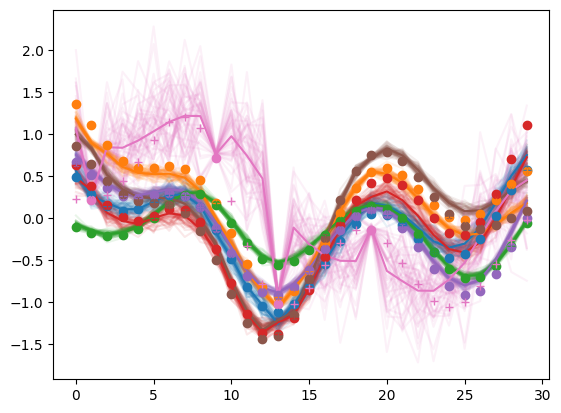

In [74]:
import torch

n_samples = 50
i = 11

qz_x = gpvae.model.backbone.encode(torch.tensor(X[:20]).float())
for _ in range(n_samples):
    z = qz_x.rsample()
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
    plt.plot(X_recon[i], label = 'reconstruction', alpha = .1)
    plt.gca().set_prop_cycle(None)
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[i], label = 'mean reconstruction')
plt.gca().set_prop_cycle(None)
X_0 = np.copy(X[i])
X_0[X_0==0] = np.nan
plt.plot(X_0,'o', label = 'Input')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i],'+', label = 'Input')
plt.show();

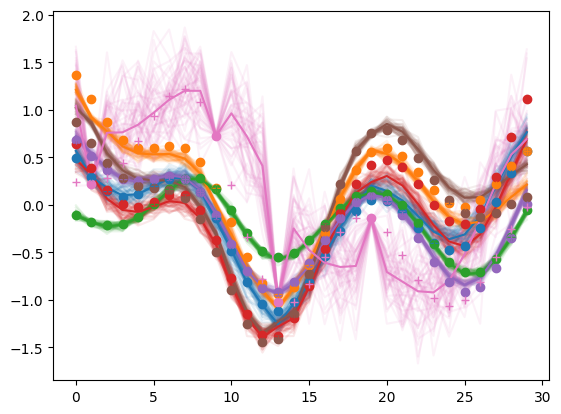

In [81]:
import torch

n_samples = 50
i = 11

qz_x = gpvae.model.backbone.encode(torch.tensor(X[:20]).float())
for _ in range(n_samples):
    z = qz_x.rsample()
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
    plt.plot(X_recon[i], label = 'reconstruction', alpha = .1)
    plt.gca().set_prop_cycle(None)
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[i], label = 'mean reconstruction')
plt.gca().set_prop_cycle(None)
X_0 = np.copy(X[i])
X_0[X_0==0] = np.nan
plt.plot(X_0,'o', label = 'Input')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i],'+', label = 'Input')
plt.show();

In [82]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
#gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = n_new_dims, latent_size = latent_size)
#gpvae.gp.p = 0.1 # ratio of imputation of the dataset
gpvae.fit_kernel(dataset_train)  # train the model to learn the kernel parameters

fitting kernel


Epoch 1/20: 55it [00:02, 25.62it/s]


Epoch 1/20: Average Loss = 0.044437


Epoch 2/20: 55it [00:02, 22.81it/s]


Epoch 2/20: Average Loss = 0.044907


...

Epoch 4/20: Average Loss = 0.044504


Epoch 5/20: 55it [00:02, 25.18it/s]


Epoch 5/20: Average Loss = 0.044909


Epoch 6/20: 40it [00:01, 23.67it/s]


KeyboardInterrupt: 

## Visualisation: embed the first 10 time series, use the GP scheme to correct, and plot reconstruction

In [83]:
X_torch = torch.tensor(X).float()[:20]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)
X_recon = gpvae.model.backbone.decode(embedding.mean).mean

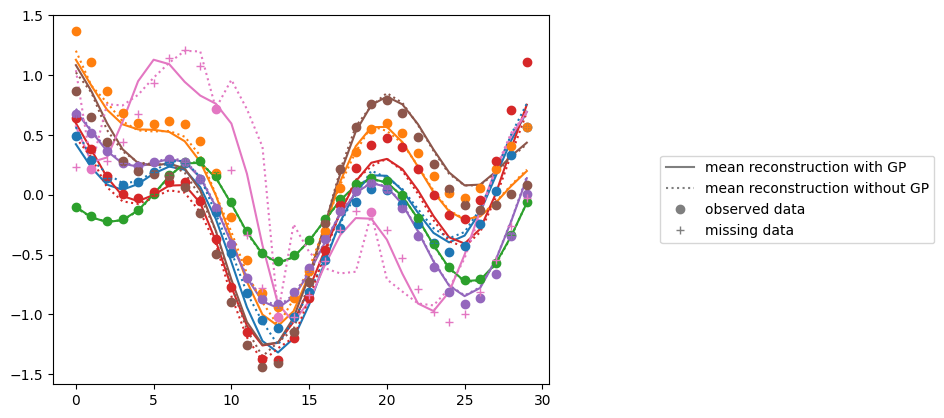

In [84]:
i = 11 ## reconstruct time series number i
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach())
plt.plot([], label = 'mean reconstruction with GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':')
plt.plot([], ':', label = 'mean reconstruction without GP')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o');
plt.plot([], 'o', label = 'observed data')
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+');
plt.plot([], '+', label = 'missing data')
plt.legend(bbox_to_anchor=[1.5, 0.5], 
           loc='center')